# Tree Tensor Network evaluation of QAOA for random regular graphs of large girth

For a depth-$p$ QAOA circuit, $\langle Z_iZ_j\rangle$ for an edge $(i,j)$ only depends on a subgraph with edges within distance $p$ of $i$ or $j$. This is already explored and implemented in the repo with LightConeEvaluator, which evaluates the energy exatly with Statevector simulation of the subgraphs. 

However, if the graph's girth is large enough relative to $p$, these subgraphs are a tree. It can then be represented directly as a Tree Tensor Network (TTN) whose topology matches the subgraph, which does not require the use of SWAPs.

We use [pytreenet](https://github.com/Udhaya2/pytreenet)'s low-level TTN primitives (`contract_nodes` + `absorb_into_open_legs` + `split_node_svd`).

In [16]:
import networkx as nx
import numpy as np
import pytreenet as ptn
from scipy.linalg import expm
import time

from qaoa_training_pipeline.evaluation.light_cone import LightConeEvaluator
from qaoa_training_pipeline.evaluation.mps_evaluator import MPSEvaluator
from qaoa_training_pipeline.evaluation.efficient_depth_one import EfficientDepthOneEvaluator
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator, operator_to_graph

X, _, Z = ptn.pauli_matrices()

## TTN causal-cone evaluator

`causal_cone_energy` builds the causal-cone tree of a single edge (reusing `LightConeEvaluator.make_radius_edges`), represents it as a TTN, applies the QAOA layers as tree-local RZZ/RX gates with bond dimension `max_bond_dim`, and reads off `<Z_iZ_j>`. `ttn_causal_cone_evaluate` sums this over all edges to get the QAOA energy.

In [ ]:
def causal_cone_energy(graph, edge, betas, gammas, max_bond_dim):
    """<Z_i Z_j> for `edge`, approximated via a bond-dimension-limited TTN of its causal cone."""
    lce = LightConeEvaluator()
    lce.graph = graph
    depth = len(betas)
    cone_edges = lce.make_radius_edges(edge, radius=depth)

    tree = nx.Graph()
    tree.add_edges_from((u, v, {"weight": w}) for (u, v), w in cone_edges.items())
    if not tree.has_edge(*edge):
        tree.add_edge(*edge, weight=graph[edge[0]][edge[1]].get("weight", 1.0))
    if not nx.is_tree(tree):
        # Cone has a cycle (graph girth too small for this depth): fall back to
        # LightConeEvaluator's exact statevector simulation for just this edge.
        circ, obs = lce.make_radius_circuit(edge, list(betas) + list(gammas))
        circ = circ.decompose()
        result = lce.primitive.run([(circ, obs)]).result()
        return float(np.real(result[0].data.evs))

    # Build a TTN whose topology is exactly the causal-cone tree.
    root = edge[0]
    degree = dict(tree.degree)
    plus_tensor = lambda n_neighbours: np.full((1,) * n_neighbours + (2,), 1 / np.sqrt(2), dtype=complex)

    ttn = ptn.TreeTensorNetworkState()
    ttn.add_root(ptn.Node(identifier=str(root)), plus_tensor(degree[root]))
    next_free_slot = {root: 0}  # next unused neighbour-leg on each node already in the TTN
    for parent, child in nx.bfs_edges(tree, root):
        ttn.add_child_to_parent(
            ptn.Node(identifier=str(child)), plus_tensor(degree[child]),
            0, str(parent), next_free_slot[parent],
        )
        next_free_slot[parent] += 1
        next_free_slot[child] = 1  # leg 0 of the child is now taken by its parent

    svd_params = ptn.SVDParameters(max_bond_dim=max_bond_dim, rel_tol=0.0, total_tol=1e-14)

    def apply_two_site_gate(id1, id2, gate):
        # Applies two-qubit gate to two nodes. When contracting the respective tensors, the information about 
        # the legs is lost, so we have to keep it to restructure the tree after splitting again
        u_legs, v_legs = ttn.legs_before_combination(id1, id2)
        ttn.contract_nodes(id1, id2, new_identifier="contr")
        ttn.absorb_into_open_legs("contr", gate)
        ttn.split_node_svd("contr", u_legs, v_legs, u_identifier=id1, v_identifier=id2, svd_params=svd_params)

    # Naive way of implementing Z_iZ_j for implementing the circuit, look into improving this
    for beta, gamma in zip(betas, gammas):
        for u, v, w in tree.edges(data="weight"):
            rzz = expm(-1j * gamma * w * np.kron(Z, Z)).reshape(2, 2, 2, 2)
            apply_two_site_gate(str(u), str(v), rzz)
        for node in tree.nodes:
            ttn.absorb_into_open_legs(str(node), expm(-1j * beta * X))
    #Compute the expectation value for one edge
    zz = ttn.operator_expectation_value(ptn.TensorProduct({str(edge[0]): Z, str(edge[1]): Z}))
    #Renormalize to avoid truncation-induced modification of the norm
    return float(np.real(zz / ttn.scalar_product()))  


def ttn_causal_cone_evaluate(cost_op, params, max_bond_dim):
    """Compute the QAOA energy by using the methods above on each edge in the cost operator and averaging"""
    depth = len(params) // 2
    betas, gammas = params[:depth], params[depth:]
    graph = operator_to_graph(cost_op)
    return sum(
        w * causal_cone_energy(graph, (u, v), betas, gammas, max_bond_dim)
        for u, v, w in graph.edges(data="weight")
    )

## Compare energy by MPS and TTN aproaches against exact statevector simulation
Compare the energies obtained on a large random regular graph between MPS and TTN. Note that in general we cannot guarantee that the girth is going to be large enough in this case.

In [18]:
random_regular_graph = nx.random_regular_graph(5, 100)
cost_op = graph_to_operator(random_regular_graph , pre_factor=-0.5)  # standard MaxCut convention

rng = np.random.default_rng(0)
depth = 1
#Random parameters, as we do not need good angles to evaluate the accuracy of an evaluation method
params = rng.uniform(-1, 1, size=2 * depth) 
# exact_energy = StatevectorEvaluator().evaluate(cost_op, list(params))
t_mps = time.time()
mps_energy = MPSEvaluator(bond_dim_circuit=32, use_swap_strategy=True, threshold_circuit=1e-14).evaluate(cost_op, params)
t_ttn = time.time()
ttn_energy = ttn_causal_cone_evaluate(cost_op, params, max_bond_dim=32)
t_eff_depth_1 = time.time()
eff_depth_one = EfficientDepthOneEvaluator().evaluate(cost_op, params)
# print(f"exact statevector energy:  {exact_energy:.10f}")
print(f"TTN causal-cone energy:    {ttn_energy:.10f}")
print(f"MPS evaluator energy:    {mps_energy:.10f}")
print(f"Efficient depth one evaluator energy:    {eff_depth_one:.10f}")

print(f"TTN causal-cone time:    {time.time() - t_ttn}")
print(f"MPS evaluator time:    {time.time() - t_mps}")
print(f"Efficient depth one evaluator time:    {time.time() - t_eff_depth_1}")

TTN causal-cone energy:    -32.2282839770
MPS evaluator energy:    -10.3516340795
Efficient depth one evaluator energy:    -32.2282839770
TTN causal-cone time:    2.1280813217163086
MPS evaluator time:    34.754331827163696
Efficient depth one evaluator time:    0.033634185791015625


## Effect of the bond dimension
Exploration of the effect of bond dimension on the TTN approach, comparing it with exact efficient depth one evaluation. At depth one and with the structure of random regular graphs, a small bond dimension suffices to provide very good approximations, as expected. 

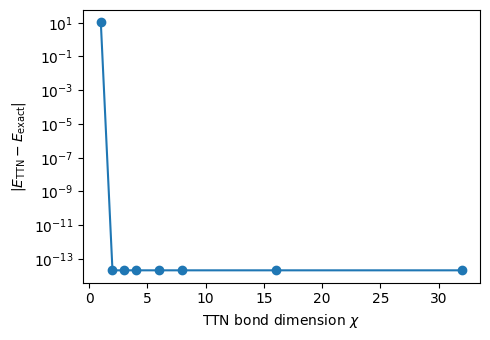

In [19]:
import matplotlib.pyplot as plt

# EfficientDepthOneEvaluator is analytically exact at p = 1, so it stands in for the
# statevector reference (which does not scale to the graph sizes used here).
exact_energy = EfficientDepthOneEvaluator().evaluate(cost_op, list(params))

bond_dimensions = [1, 2, 3, 4, 6, 8, 16, 32]
errors = [abs(ttn_causal_cone_evaluate(cost_op, params, chi) - exact_energy) for chi in bond_dimensions]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(bond_dimensions, np.maximum(errors, 1e-16), "o-")
ax.set_xlabel(r"TTN bond dimension $\chi$")
ax.set_ylabel(r"$|E_{\mathrm{TTN}} - E_{\mathrm{exact}}|$")
ax.set_yscale("log")
fig.tight_layout()

## Benchmark against MPSEvaluator
Comparison of TTN approach against `MPSEvaluator`, with `EfficientDepthOneEvaluator` and `LightConeEvaluator` as references, on random regular graphs, in this case with a guaranteed large girth by impossing girth > 2p+1

In [23]:
# Methods to generate random regular graphs that fulfill the minimum girth condition.
# This is done by construting a random d-regular graph by adding edges progressively but
# never add an edge that would create a smaller cycle than the required girth.
# We do this by assigning d "stubs" to every node in the graph, and matching the stubs randomly.
# This gives the d-regularity guarantee. However, we reject matchings that create a cycle smaller 
# than the required girth by rejecting matchings that make dist(u,v) <= girth - 2.
def random_regular_graph_min_girth(degree, num_nodes, min_girth, seed=None, max_restarts=500):
    """Generates a random d-regular graph guaranteed to have a girth bigger than min_girth. If no 
    graph is found within max_restarts tries, it raises an exception. 
    """
    rng = np.random.default_rng(seed)
    for _ in range(max_restarts):
        graph = _attempt_min_girth_pairing(degree, num_nodes, min_girth, rng)
        if graph is not None:
            return graph

    raise RuntimeError(
        f"No {degree}-regular graph on {num_nodes} nodes with girth >= {min_girth} "
        f"found in {max_restarts} restarts."
    )


def _attempt_min_girth_pairing(degree, num_nodes, min_girth, rng, stall_limit=200):
    """One node pairing attempt attempt. Returns None if it gets stuck."""
    graph = nx.empty_graph(num_nodes)
    stubs = list(np.repeat(np.arange(num_nodes), degree))
    rng.shuffle(stubs)
    stalls = 0

    while stubs:
        idx1, idx2 = rng.choice(len(stubs), size=2, replace=False)
        node1, node2 = int(stubs[idx1]), int(stubs[idx2])

        # Adding (node1, node2) closes a cycle of length d(node1, node2) + 1, so the two
        # endpoints must already be at least `min_girth - 1` hops apart.
        too_close = nx.single_source_shortest_path_length(graph, node1, cutoff=min_girth - 2)
        if node1 == node2 or node2 in too_close:
            stalls += 1
            if stalls > stall_limit:
                return None
            continue

        graph.add_edge(node1, node2, weight=1.0)
        for idx in sorted((idx1, idx2), reverse=True):
            stubs.pop(idx)
        stalls = 0

    return graph


def all_cones_are_trees(graph, depth):
    """True if every edge's depth-`depth` reverse causal cone is a tree."""
    lce = LightConeEvaluator()
    lce.graph = graph
    return all(
        nx.is_tree(nx.Graph(list(lce.make_radius_edges(edge, radius=depth))))
        for edge in graph.edges
    )


DEGREE = 3                  # degree of the random regular graphs
DEPTH = 1                   # QAOA depth; EfficientDepthOneEvaluator only exists at p = 1
MIN_GIRTH = 2 * DEPTH + 3   # girth needed for every depth-p causal cone to be a tree

demo_graph = random_regular_graph_min_girth(DEGREE, 40, MIN_GIRTH, seed=0)
print(f"degree {DEGREE}, girth {nx.girth(demo_graph)} (need >= {MIN_GIRTH}), "
      f"every depth-{DEPTH} cone is a tree: {all_cones_are_trees(demo_graph, DEPTH)}")

degree 3, girth 5 (need >= 5), every depth-1 cone is a tree: True


### Comment on the graph girth
It looks like the greater the girth, the better the evaluation results with TTN. This might be something to explore further. Intuitively it makes sense, but also this should be explored taking into account the Fixed Angle Conjecture, which says that graphs with girth greater than 2p+1 are worst case for QAOA and MaxCut in terms of approximation ratio. This means that the energy given by these graphs might be well evaluated by TTNs but the overall approximation ratio might be worst case.  

In [24]:
#Perform the benchmark of the different evaluators

GRAPH_SIZES = [10, 14, 20, 40, 60, 80]  # number of nodes; `DEGREE * n` must be even
NUM_INSTANCES = 5                      # random instances per size
BOND_DIM = 32                           # shared by the TTN and the MPS evaluator
BENCH_PARAMS = [0.4, 0.6]               # [beta_0, gamma_0], near the p=1 cubic-MaxCut optimum

# Evaluators are rebuilt for every measurement, so each timing includes its own setup cost
# and nothing is cached across instances.
BENCH_EVALUATORS = {
    "TTN causal cone": lambda op, prm: ttn_causal_cone_evaluate(op, prm, max_bond_dim=BOND_DIM),
    "MPS": lambda op, prm: MPSEvaluator(
        bond_dim_circuit=BOND_DIM, use_swap_strategy=True, threshold_circuit=1e-14,
    ).evaluate(op, prm),
    "EfficientDepthOne": lambda op, prm: EfficientDepthOneEvaluator().evaluate(op, prm),
    "LightCone": lambda op, prm: LightConeEvaluator().evaluate(op, prm),
}

records = []
for num_nodes in GRAPH_SIZES:
    for instance in range(NUM_INSTANCES):
        bench_graph = random_regular_graph_min_girth(
            DEGREE, num_nodes, MIN_GIRTH, seed=1000 * num_nodes + instance
        )
        bench_op = graph_to_operator(bench_graph, pre_factor=-0.5)  # MaxCut convention

        energies, runtimes = {}, {}
        for name, evaluate in BENCH_EVALUATORS.items():
            tic = time.perf_counter()
            energies[name] = float(evaluate(bench_op, BENCH_PARAMS))
            runtimes[name] = time.perf_counter() - tic

        # EfficientDepthOne is analytically exact at p = 1, so it is the accuracy reference.
        reference = energies["EfficientDepthOne"]
        records += [
            {
                "evaluator": name,
                "num_nodes": num_nodes,
                "instance": instance,
                "runtime": runtimes[name],
                "rel_error": abs(energies[name] - reference) / abs(reference),
            }
            for name in BENCH_EVALUATORS
        ]

        print(f"n={num_nodes:3d} instance={instance}  " + "  ".join(
            f"{name}: {runtimes[name]:7.2f}s" for name in BENCH_EVALUATORS), flush=True)

n= 10 instance=0  TTN causal cone:    0.07s  MPS:    1.01s  EfficientDepthOne:    0.00s  LightCone:    0.28s
n= 10 instance=1  TTN causal cone:    0.03s  MPS:    0.10s  EfficientDepthOne:    0.00s  LightCone:    0.13s
n= 10 instance=2  TTN causal cone:    0.03s  MPS:    0.05s  EfficientDepthOne:    0.00s  LightCone:    0.12s
n= 10 instance=3  TTN causal cone:    0.03s  MPS:    0.09s  EfficientDepthOne:    0.00s  LightCone:    0.18s
n= 10 instance=4  TTN causal cone:    0.02s  MPS:    0.09s  EfficientDepthOne:    0.00s  LightCone:    0.14s
n= 14 instance=0  TTN causal cone:    0.03s  MPS:    0.19s  EfficientDepthOne:    0.00s  LightCone:    0.17s
n= 14 instance=1  TTN causal cone:    0.03s  MPS:    0.16s  EfficientDepthOne:    0.00s  LightCone:    0.15s
n= 14 instance=2  TTN causal cone:    0.08s  MPS:    0.16s  EfficientDepthOne:    0.00s  LightCone:    0.15s
n= 14 instance=3  TTN causal cone:    0.03s  MPS:    0.14s  EfficientDepthOne:    0.00s  LightCone:    0.33s
n= 14 instance=4  T

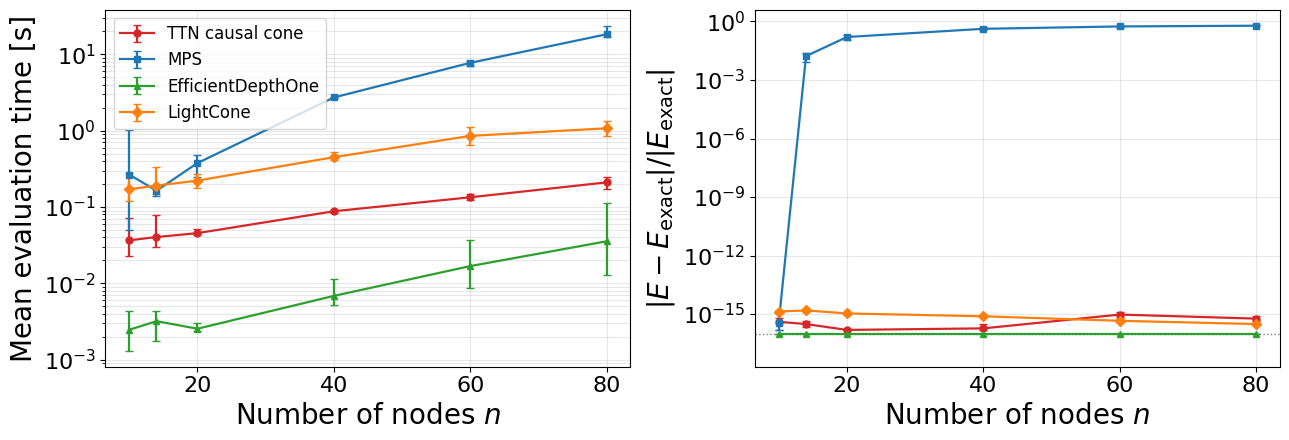

In [25]:
#Plot the results obtained in the benchmark
import matplotlib.pyplot as plt

STYLES = {
    "TTN causal cone": {"color": "tab:red", "marker": "o"},
    "MPS": {"color": "tab:blue", "marker": "s"},
    "EfficientDepthOne": {"color": "tab:green", "marker": "^"},
    "LightCone": {"color": "tab:orange", "marker": "D"},
}
FLOOR = 1e-16  # relative errors are clipped here so the exact evaluators stay on the log axis

fig, (ax_time, ax_error) = plt.subplots(1, 2, sharex=True, figsize=(13, 4.5))

for name, style in STYLES.items():
    rows = [r for r in records if r["evaluator"] == name]
    sizes = sorted({r["num_nodes"] for r in rows})
    runtimes = [[r["runtime"] for r in rows if r["num_nodes"] == n] for n in sizes]
    errors = [[max(r["rel_error"], FLOOR) for r in rows if r["num_nodes"] == n] for n in sizes]

    for axis, per_size in ((ax_time, runtimes), (ax_error, errors)):
        means = [np.mean(values) for values in per_size]
        low = [np.clip(mean - np.min(values),0, None) for mean, values in zip(means, per_size)]
        high = [np.clip(np.max(values) - mean,0, None) for mean, values in zip(means, per_size)]
        axis.errorbar(sizes, means, yerr=[low, high], label=name, capsize=3, lw=1.6, ms=5,
                      **style)

ax_time.set_ylabel("Mean evaluation time [s]", fontsize=20)
ax_time.set_xlabel("Number of nodes $n$", fontsize=20)
ax_time.set_yscale("log")
# ax_time.set_title(f"{DEGREE}-regular, girth $\\geq$ {MIN_GIRTH}, $p={DEPTH}$, "
#                 f"$\\chi={BOND_DIM}$, {NUM_INSTANCES} instances/size")
ax_time.legend(fontsize=12, loc="upper left")

ax_error.set_ylabel(r"$|E - E_\mathrm{exact}| / |E_\mathrm{exact}|$", fontsize=20)
ax_error.set_xlabel("Number of nodes $n$", fontsize=20)
ax_error.set_yscale("log")
ax_error.set_ylim(bottom=FLOOR / 50)  # room under the floor line for its label
ax_error.axhline(FLOOR, color="gray", ls=":", lw=1)

for axis in (ax_time, ax_error):
    axis.grid(alpha=0.3, which="both")
    axis.tick_params(axis="both", labelsize=16)


fig.tight_layout()